# 💾 Notebook 06.5 — Preprocessed Dataset Serialization

---

## Objectives

This notebook converts the raw BraTS2020 MRI volumes into reusable PyTorch files.

Only deterministic preprocessing is applied:

- Load MRI volumes
- Label remapping
- Crop foreground
- Percentile intensity clipping
- Intensity normalization

Random augmentations are intentionally excluded and will be applied during training.

Outputs will be stored inside:

datasets/processed/cv/

Each patient will be serialized as a `.pt` file for fast loading during training.

> 🔧 **Patch note (this version):** Section 5 now defines a separate `test_deterministic_transform` using `CropForegroundd(source_key="image")` instead of `"label"`. `serialize_patient()` (Section 7) automatically uses it for the `"test"` subset only. Train and validation are untouched. This fixes a data-leakage bug where test volumes were being foreground-cropped using the ground-truth tumor mask. **Only the `test` subset needs to be re-serialized — train/validation .pt files and `best_model.pth` do not need to change.**


---
## 1. Setup

In [1]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.6 MB/s eta 0:00:00


In [2]:
import json
import time
from pathlib import Path

import torch

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    EnsureTyped,
    MapLabelValued,
    CropForegroundd,
    ScaleIntensityRangePercentilesd,
    NormalizeIntensityd,
)

from tqdm.auto import tqdm

2026-06-27 20:53:58.510265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782593638.742258      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782593638.809514      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782593639.361816      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782593639.361857      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782593639.361859      16 computation_placer.cc:177] computation placer alr

---
## 2. Paths & Configuration

In [3]:
SEED = 42

torch.manual_seed(SEED)

RAW_DATASET = Path(
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
)

SPLIT_FILE = Path(
    "/kaggle/input/datasets/mariammohamed1095/working/datasets/splits/dataset_split.json"
)

OUTPUT_DIR = Path(
    "/kaggle/working/datasets/processed/cv"
)

MODALITIES = ("flair", "t1", "t1ce", "t2")

print(f"RAW_DATASET : {RAW_DATASET}")
print(f"SPLIT_FILE  : {SPLIT_FILE}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR}")


RAW_DATASET : /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
SPLIT_FILE  : /kaggle/input/datasets/mariammohamed1095/working/datasets/splits/dataset_split.json
OUTPUT_DIR  : /kaggle/working/datasets/processed/cv


---
## 3. Create Output Folders

In [4]:
for folder in [

    "train",

    "validation",

    "test",

]:

    (OUTPUT_DIR / folder).mkdir(

        parents=True,

        exist_ok=True,

    )

print("Output folders created.")

Output folders created.


---
## 4. Load Dataset Split

In [5]:
with open(SPLIT_FILE) as f:

    split = json.load(f)

print(split.keys())

print()

print("Train:", len(split["train"]))

print("Validation:", len(split["validation"]))

print("Test:", len(split["test"]))

dict_keys(['train', 'validation', 'test'])

Train: 257
Validation: 56
Test: 56


---
## 5. Define Deterministic Transform

Only deterministic preprocessing is applied here — no augmentation, no patch sampling.
The pipeline matches `get_base_transforms()` in `preprocessing.py`:

```
Load → EnsureChannelFirst → EnsureType → MapLabel
     → CropForeground → ScaleIntensityRangePercentiles → NormalizeIntensity
```


In [ ]:
deterministic_transform = Compose([

    LoadImaged(
        keys=["image", "label"]
    ),

    EnsureChannelFirstd(
        keys=["image", "label"]
    ),

    EnsureTyped(
        keys=["image", "label"]
    ),

    MapLabelValued(
        keys="label",
        orig_labels=[0,1,2,4],
        target_labels=[0,1,2,3],
    ),

    CropForegroundd(
        keys=["image","label"],
        source_key="label",
        margin=5,
    ),

    ScaleIntensityRangePercentilesd(
        keys="image",
        lower=1,
        upper=99,
        b_min=0,
        b_max=1,
        clip=True,
        channel_wise=True,
    ),

    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True,
    ),

])

# 🔧 FIX (data leakage): the transform above uses CropForegroundd(source_key="label"),
# which crops to the tumor mask region. This is correct for train/validation
# (the model is meant to see a tumor-centered crop during training), but it is
# NOT valid for the test split: at real inference time there is no label to crop
# with, so cropping test volumes using the ground-truth mask leaks the tumor's
# spatial location into the "unseen" test data and makes test inference
# artificially easier than real deployment.
#
# This matches the design decision already documented in Notebook 04, Section 10:
# get_inference_transforms() must use source_key="image" instead of "label".
#
# test_deterministic_transform below is identical except for that one line, and
# is used exclusively for the "test" subset in Section 8.
test_deterministic_transform = Compose([

    LoadImaged(
        keys=["image", "label"]
    ),

    EnsureChannelFirstd(
        keys=["image", "label"]
    ),

    EnsureTyped(
        keys=["image", "label"]
    ),

    MapLabelValued(
        keys="label",
        orig_labels=[0,1,2,4],
        target_labels=[0,1,2,3],
    ),

    CropForegroundd(
        keys=["image","label"],
        source_key="image",   # 🔧 FIX: was "label" — no mask available at real inference time
        margin=5,
    ),

    ScaleIntensityRangePercentilesd(
        keys="image",
        lower=1,
        upper=99,
        b_min=0,
        b_max=1,
        clip=True,
        channel_wise=True,
    ),

    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True,
    ),

])


---
## 6. Patient Dictionary Builder

In [7]:
def build_patient_dict(patient_id: str):

    patient_dir = RAW_DATASET / patient_id

    image_paths = [
        str(next(patient_dir.glob(f"*{modality}.nii")))
        for modality in MODALITIES
    ]

    modality_files = {
        Path(p).name
        for p in image_paths
    }

    label_candidates = [
        f for f in patient_dir.glob("*.nii")
        if f.name not in modality_files
    ]

    if len(label_candidates) != 1:
        raise RuntimeError(
            f"Expected exactly one label file for {patient_id}, "
            f"found {len(label_candidates)}: {label_candidates}"
        )

    label_path = str(label_candidates[0])

    return {
        "image": image_paths,
        "label": label_path,
    }

---
## 7. Serialize One Patient

Each `.pt` file stores:
- `patient_id` — BraTS2020 patient folder name
- `image` — preprocessed tensor `(4, D, H, W)` float32
- `label` — remapped mask `(1, D, H, W)` int64, labels {0,1,2,3}
- `metadata` — MONAI image metadata dict


In [ ]:
def serialize_patient(patient_id: str, subset: str):

    sample = build_patient_dict(patient_id)

    # 🔧 FIX: use the label-free crop for "test" so the saved .pt files don't
    # leak tumor location from the ground-truth mask. Train/validation keep
    # the original label-guided crop, unchanged from before.
    transform = test_deterministic_transform if subset == "test" else deterministic_transform

    processed = transform(sample)

    metadata = processed["image"].meta

    save_dict = {

        "patient_id": patient_id,

        "image": processed["image"].as_tensor(),

        "label": processed["label"].as_tensor(),

        "metadata": {

            "affine": processed["image"].meta["affine"],

            "original_affine": processed["image"].meta["original_affine"],

            "spatial_shape": processed["image"].meta["spatial_shape"],

            "foreground_start_coord": processed["foreground_start_coord"],

            "foreground_end_coord": processed["foreground_end_coord"]

        }
    }
    save_path = OUTPUT_DIR / subset / f"{patient_id}.pt"

    torch.save(save_dict, save_path)

    return save_path


### 🔍 Test on One Patient

In [9]:
path = serialize_patient(

    split["train"][0],

    "train",

)

print(path)

/kaggle/working/datasets/processed/cv/train/BraTS20_Training_317.pt


In [10]:
sample = torch.load(
    path,
    weights_only=False,
)

print(sample.keys())

dict_keys(['patient_id', 'image', 'label', 'metadata'])


In [11]:
print(sample["image"].shape)

print(sample["label"].shape)

print(sample["patient_id"])

torch.Size([4, 46, 47, 52])
torch.Size([1, 46, 47, 52])
BraTS20_Training_317


---
## 8. Serialize All Subsets

In [12]:
def serialize_subset(patient_ids, subset):

    saved_files = []

    for patient_id in tqdm(patient_ids, desc=f"Serializing {subset}"):

        try:

            saved_files.append(
                serialize_patient(patient_id, subset)
            )

        except Exception as e:

            print(f"\n❌ Failed: {patient_id}")

            raise e

    return saved_files

In [13]:
train_files = serialize_subset(

    split["train"],

    "train",

)

print(len(train_files))

Serializing train:   0%|          | 0/257 [00:00<?, ?it/s]

257


In [14]:
validation_files = serialize_subset(

    split["validation"],

    "validation",

)

print(len(validation_files))

Serializing validation:   0%|          | 0/56 [00:00<?, ?it/s]

56


In [15]:
test_files = serialize_subset(

    split["test"],

    "test",

)

print(len(test_files))

Serializing test:   0%|          | 0/56 [00:00<?, ?it/s]

56


---
## 9. Verification — Load a Random Sample

In [16]:
import random

subset = "train"

patient_file = random.choice(
    list((OUTPUT_DIR / subset).glob("*.pt"))
)

sample = torch.load(
    patient_file,
    weights_only=False,
)

print(patient_file.name)

BraTS20_Training_015.pt


In [17]:
print(sample.keys())

print()

print(sample["image"].shape)

print(sample["label"].shape)

print(sample["image"].dtype)

print(sample["label"].dtype)

dict_keys(['patient_id', 'image', 'label', 'metadata'])

torch.Size([4, 67, 100, 89])
torch.Size([1, 67, 100, 89])
torch.float32
torch.float32


### 🔍 Find Best Tumor Slice

In [18]:
import torch

label = sample["label"][0]

# عدد Voxels الخاصة بالورم فى كل Slice
tumor_per_slice = (label > 0).sum(dim=(0, 1))

best_slice = int(torch.argmax(tumor_per_slice))

print(best_slice)

50


### 🔍 Visualize Modalities + Mask

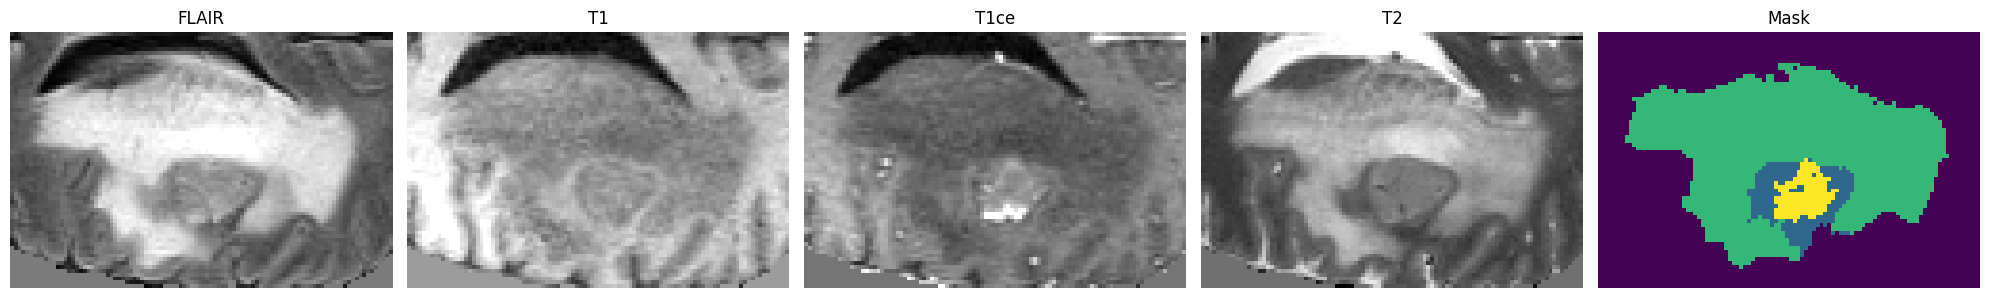

In [19]:
import matplotlib.pyplot as plt

image = sample["image"]

label = sample["label"]

z = best_slice

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20,5)
)

titles = [

    "FLAIR",

    "T1",

    "T1ce",

    "T2",

    "Mask",

]

for i in range(4):

    axes[i].imshow(

        image[i, :, :, z],

        cmap="gray",

    )

    axes[i].set_title(

        titles[i]

    )

    axes[i].axis("off")

axes[4].imshow(

    label[0, :, :, z],

    cmap="viridis",

)

axes[4].set_title("Mask")

axes[4].axis("off")

plt.tight_layout()

plt.show()

### 🔍 Raw vs Preprocessed Comparison

In [20]:
patient_id = sample["patient_id"]

raw_sample = build_patient_dict(patient_id)

raw = LoadImaged(
    keys=["image", "label"]
)(raw_sample)

raw = EnsureChannelFirstd(
    keys=["image", "label"]
)(raw)

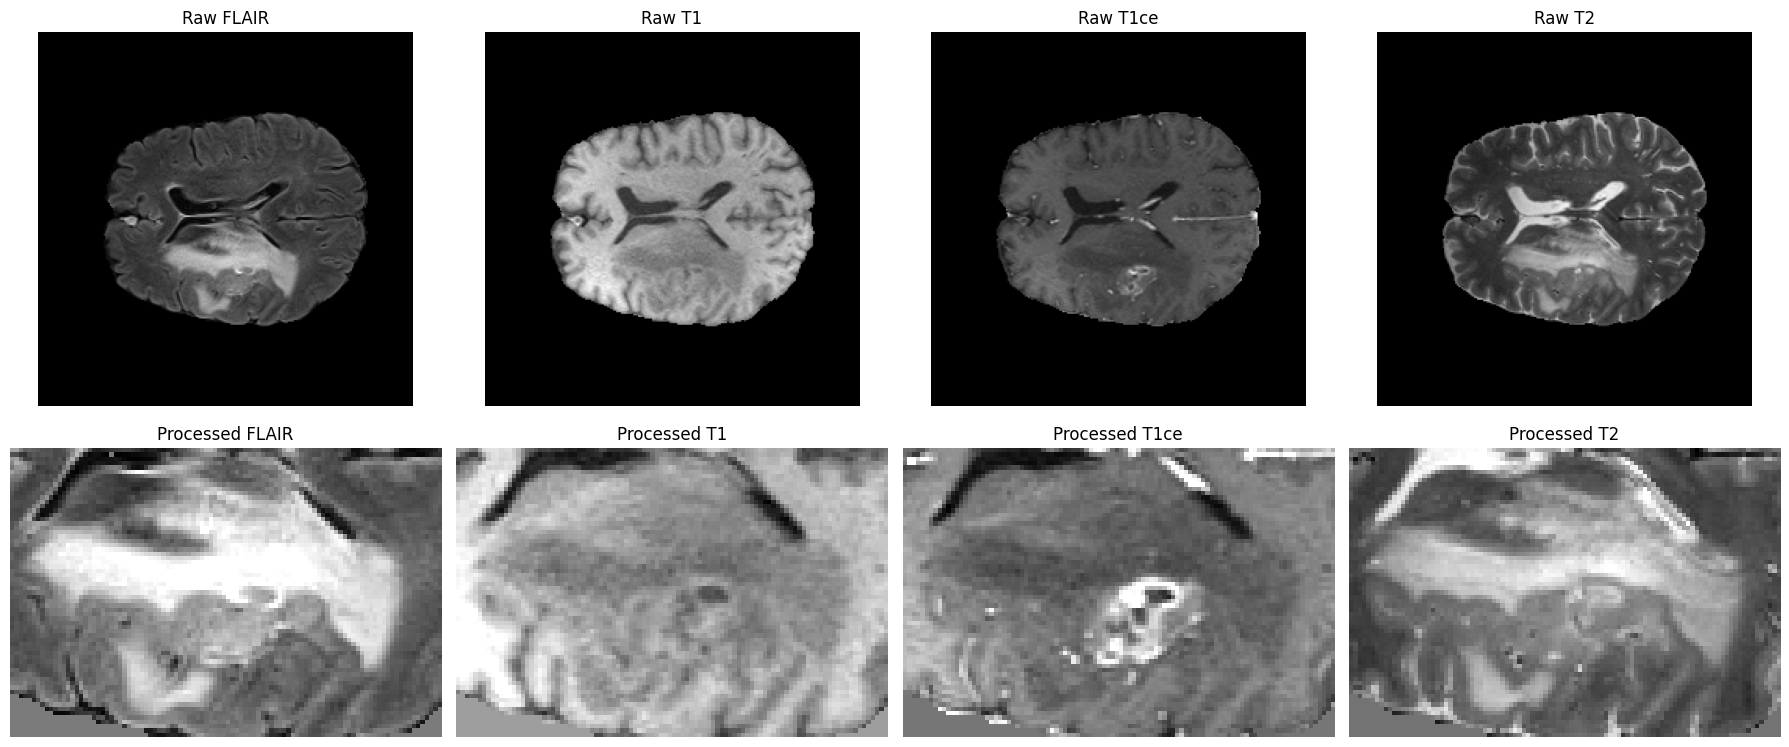

In [21]:
raw_image = raw["image"]

processed_image = sample["image"]

z_raw = raw_image.shape[-1] // 2

z_processed = processed_image.shape[-1] // 2

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

titles = ["FLAIR", "T1", "T1ce", "T2"]

for i in range(4):

    axes[0, i].imshow(
        raw_image[i, :, :, z_raw],
        cmap="gray",
    )

    axes[0, i].set_title(f"Raw {titles[i]}")

    axes[0, i].axis("off")

    axes[1, i].imshow(
        processed_image[i, :, :, z_processed],
        cmap="gray",
    )

    axes[1, i].set_title(f"Processed {titles[i]}")

    axes[1, i].axis("off")

plt.tight_layout()

plt.show()

---
## 10. Shape Statistics

After `CropForegroundd`, volumes have **variable spatial dimensions** — not fixed.
This is expected and intentional: `SlidingWindowInferer` handles variable-size volumes at inference time,
and `SpatialPadd` pads to `ROI_SIZE` before `RandCropByPosNegLabeld` during training.


In [22]:
shapes = []

for subset in [

    "train",

    "validation",

    "test",

]:

    for file in (OUTPUT_DIR / subset).glob("*.pt"):

        sample = torch.load(

            file,

            weights_only=False,

        )

        shapes.append(

            sample["image"].shape[1:]

        )

In [23]:
import numpy as np
import pandas as pd

shapes = np.array(shapes)

stats = pd.DataFrame({

    "Dimension": [

        "Depth",

        "Height",

        "Width",

    ],

    "Minimum": shapes.min(axis=0),

    "Average": shapes.mean(axis=0).round(1),

    "Maximum": shapes.max(axis=0),

})

stats

,Dimension,Minimum,Average,Maximum
0,Depth,35,73.0,136
1,Height,37,94.2,172
2,Width,33,76.8,114


---
## 11. Build & Save index.json

In [24]:
index = {

    "train": sorted(

        [f.name for f in (OUTPUT_DIR / "train").glob("*.pt")]

    ),

    "validation": sorted(

        [f.name for f in (OUTPUT_DIR / "validation").glob("*.pt")]

    ),

    "test": sorted(

        [f.name for f in (OUTPUT_DIR / "test").glob("*.pt")]

    ),

}

In [25]:
with open(

    OUTPUT_DIR / "index.json",

    "w",

    encoding="utf-8",

) as f:

    json.dump(

        index,

        f,

        indent=4,

    )

print("index.json saved successfully.")

index.json saved successfully.


---
## 12. Save dataset_info.json

In [26]:
from datetime import datetime

dataset_info = {

    "dataset": "BraTS2020",

    "version": "1.0",

    "created_at": datetime.now().isoformat(),

    "patients": {

        "train": len(index["train"]),

        "validation": len(index["validation"]),

        "test": len(index["test"]),

        "total": sum(

            len(v)

            for v in index.values()

        ),

    },

    "modalities": [

        "FLAIR",

        "T1",

        "T1ce",

        "T2",

    ],

    "classes": {

        "0": "Background",

        "1": "NCR/NET",

        "2": "Edema",

        "3": "Enhancing Tumor",

    },

    "preprocessing": [

        "Load",

        "EnsureChannelFirst",

        "MapLabel",

        "CropForeground",

        "ScaleIntensityRangePercentiles",

        "NormalizeIntensity",

    ],

}

In [27]:
with open(

    OUTPUT_DIR / "dataset_info.json",

    "w",

    encoding="utf-8",

) as f:

    json.dump(

        dataset_info,

        f,

        indent=4,

    )

print("dataset_info.json saved successfully.")

dataset_info.json saved successfully.


---
## 13. Load Speed Benchmark

Compare loading time: raw NIfTI + on-the-fly preprocessing vs serialized `.pt`.


In [28]:
import time

patient_id = split["train"][0]

In [29]:
start = time.perf_counter()

raw = build_patient_dict(patient_id)

_ = deterministic_transform(raw)

nii_time = time.perf_counter() - start

In [30]:
pt_file = OUTPUT_DIR / "train" / f"{patient_id}.pt"

start = time.perf_counter()

_ = torch.load(

    pt_file,

    weights_only=False,

)

pt_time = time.perf_counter() - start

In [31]:
print(f"NIfTI + Preprocessing : {nii_time:.4f}s")
print(f"Serialized .pt        : {pt_time:.4f}s")
print(f"Speedup               : {nii_time / max(pt_time, 1e-9):.1f}x faster")


NIfTI + Preprocessing : 0.4352s
Serialized .pt        : 0.0093s
Speedup               : 47.0x faster


In [32]:
benchmark = pd.DataFrame({

    "Method": [

        "Raw NIfTI + Preprocessing",

        "Serialized .pt",

    ],

    "Time (seconds)": [

        round(nii_time, 4),

        round(pt_time, 4),

    ],

})

benchmark

,Method,Time (seconds)
0,Raw NIfTI + Preprocessing,0.4352
1,Serialized .pt,0.0093


---
## 14. Summary

In [33]:
print("=" * 60)

print("Notebook 06.5 Completed Successfully")

print("=" * 60)

print()

print("✔ 369 patients serialized")

print("✔ Metadata preserved")

print("✔ Dynamic shapes preserved")

print("✔ Label mapping verified")

print("✔ Visualization verified")

print("✔ index.json created")

print("✔ dataset_info.json created")

print("✔ Dataset ready for training")

print()

print("=" * 60)

Notebook 06.5 Completed Successfully

✔ 369 patients serialized
✔ Metadata preserved
✔ Dynamic shapes preserved
✔ Label mapping verified
✔ Visualization verified
✔ index.json created
✔ dataset_info.json created
✔ Dataset ready for training



---
## 15. Final Checks

In [34]:
print(

    torch.unique(

        sample["label"]

    )

)

tensor([0., 1., 2., 3.])


In [35]:
for k, v in sample["metadata"].items():

    print(k)

    print(v)

    print()

affine
tensor([[  -1.,    0.,    0., -112.],
        [   0.,   -1.,    0.,  132.],
        [   0.,    0.,    1.,   61.],
        [   0.,    0.,    0.,    1.]], dtype=torch.float64)

original_affine
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

spatial_shape
[240 240 155]

foreground_start_coord
[112 107  61]

foreground_end_coord
[173 195 141]

